### This notebook is intended to study and analyse the effect of outliers during feature scaling.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# here i have created my own dataframe
df = pd.DataFrame(
    {"age":[20,23,25,19,29,27,45,32,78,64],
    "income":[30000,40000,56000,18000,32000,26000,67000,120000,43000,55000],
    "purchased":["yes","no","yes","no","yes","no","yes","yes","no","yes"]
    })
df

,age,income,purchased
0,20,30000,yes
1,23,40000,no
2,25,56000,yes
3,19,18000,no
4,29,32000,yes
5,27,26000,no
6,45,67000,yes
7,32,120000,yes
8,78,43000,no
9,64,55000,yes


In [3]:
myData = df[["age","income"]]
myData.columns

Index(['age', 'income'], dtype='object')

## Visualizing effect of standardization and normalization on distribution of data

In [4]:
#scale the data uisng z-score normalization using class StanndardScaler
scaler = StandardScaler()
myData_scaled = scaler.fit_transform(myData) # we are fitting and transforming in one step
myData_scaled = pd.DataFrame(myData_scaled, columns=myData.columns)

In [5]:
 # we can also scale the data using normalization (MinMax normalization)
normalizer = MinMaxScaler()
myData_normalized = normalizer.fit_transform(myData)
myData_normalized = pd.DataFrame(myData_normalized,columns=myData.columns)

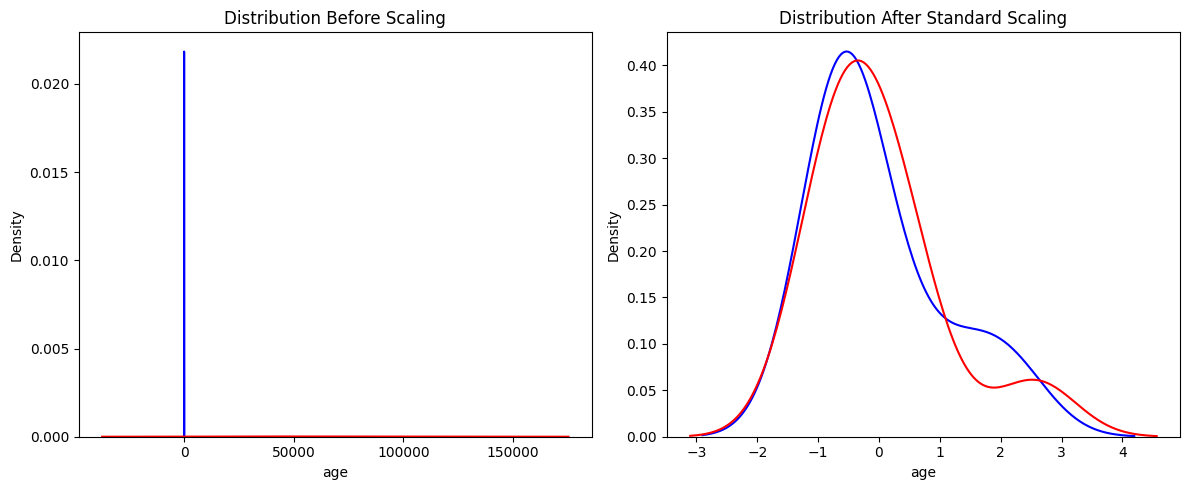

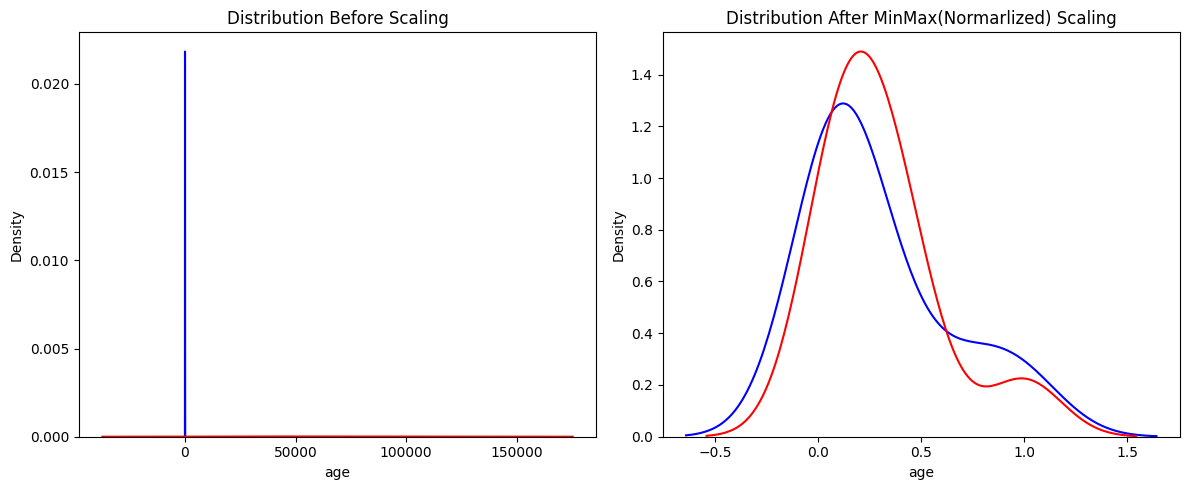

In [6]:
#  distribution plot on standard scaling
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(12,5)) # this line is just to display plots side by side 

# left plot
ax1.set_title("Distribution Before Scaling")
sns.kdeplot(myData,x="age",color="blue",fill=False, ax=ax1)
sns.kdeplot(myData,x="income",color="red",fill=False,ax=ax1)


# right plot 
ax2.set_title("Distribution After Standard Scaling")
sns.kdeplot(myData_scaled,x="age",color="blue",fill=False,ax=ax2)
sns.kdeplot(myData_scaled,x="income",color="red",fill=False,ax=ax2)

plt.tight_layout()
plt.show() # prediction: when scaled, all the values will be in equal footing (with in a small range), so the distribution plot might look like a regular guassian bell curve

# distribution plot on normalized scaling 
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(12,5)) # this line is just to display plots side by side 

# left plot
ax1.set_title("Distribution Before Scaling")
sns.kdeplot(myData,x="age",color="blue",fill=False, ax=ax1)
sns.kdeplot(myData,x="income",color="red",fill=False,ax=ax1)


# right plot
ax2.set_title("Distribution After MinMax(Normarlized) Scaling")
sns.kdeplot(myData_normalized,x="age",color="blue",fill=False,ax=ax2)
sns.kdeplot(myData_normalized,x="income",color="red",fill=False,ax=ax2)

plt.tight_layout()
plt.show() # prediction: since all the vaules are scaled bw 0 and 1.they are in equal footing and it's distribution plot may also look like a normal gaussian bell curve

##  Visualizing effect of standardization and normalization on relationship bw variables using scatterplots

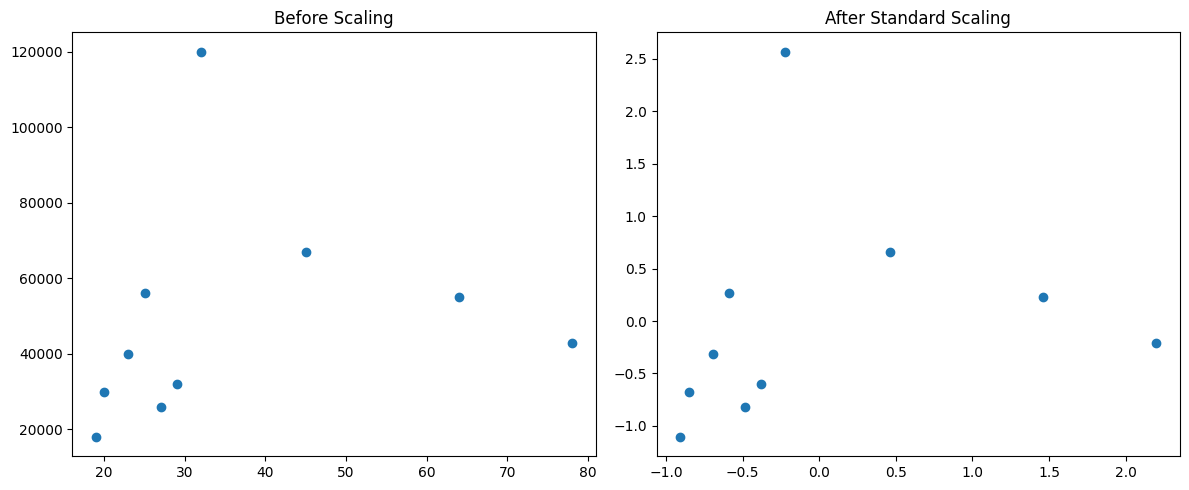

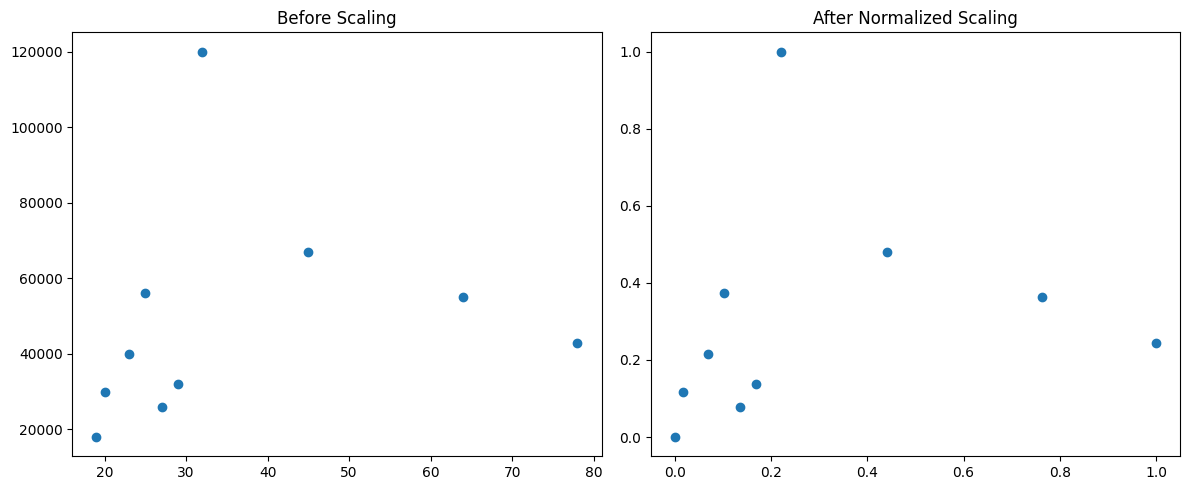

In [7]:
# scatter plot on standardization 
fig,(ax1,ax2)= plt.subplots(ncols=2,figsize=(12,5))

# left plot
ax1.set_title("Before Scaling")
ax1.scatter(myData["age"],myData["income"])

# right plot
ax2.set_title("After Standard Scaling")
ax2.scatter(myData_scaled["age"],myData_scaled["income"])

plt.tight_layout()
plt.show() # prediction: i think there is no effect of scaling on the data, the shape and structure remains same. only scale differs.


# scatter plot on normalization
fig,(ax1,ax2)= plt.subplots(ncols=2,figsize=(12,5))

# left plot
ax1.set_title("Before Scaling")
ax1.scatter(myData["age"],myData["income"])

# right plot
ax2.set_title("After Normalized Scaling")
ax2.scatter(myData_normalized["age"],myData_normalized["income"])

plt.tight_layout()
plt.show() # prediction: no effect of normalization on scaling. maybe only scale will change


## Injecting Outliers in the Cusotm Dataset and Analyzing the Impacts

In [21]:
outliers = pd.DataFrame({"age":[4,100,40],"income":[500000,3000000,9000]}) # i have added some extreme outliers here
myData = pd.concat([myData,outliers],ignore_index=True)
myData


,age,income
0,20,30000
1,23,40000
2,25,56000
3,19,18000
4,29,32000
5,27,26000
6,45,67000
7,32,120000
8,78,43000
9,64,55000


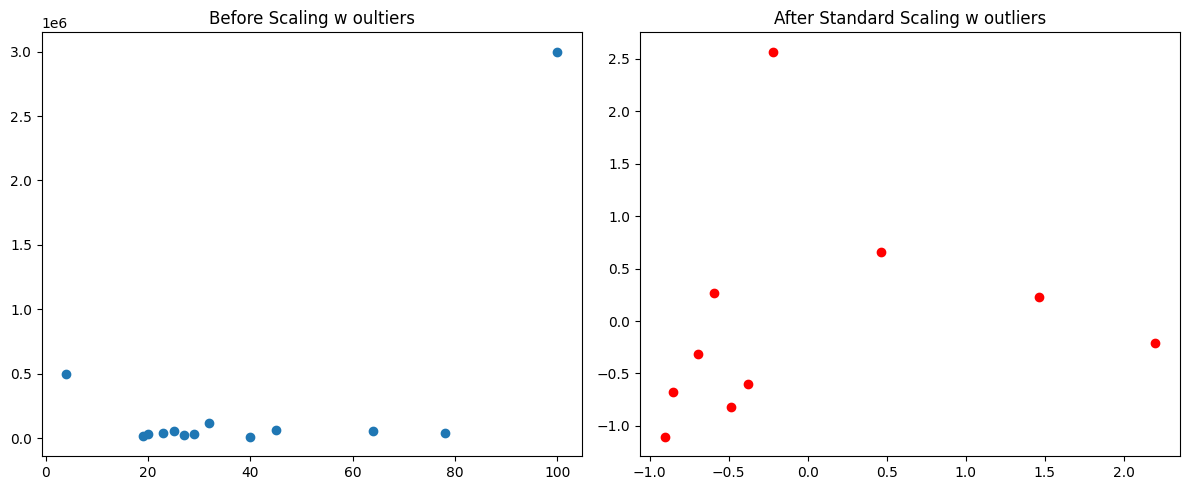

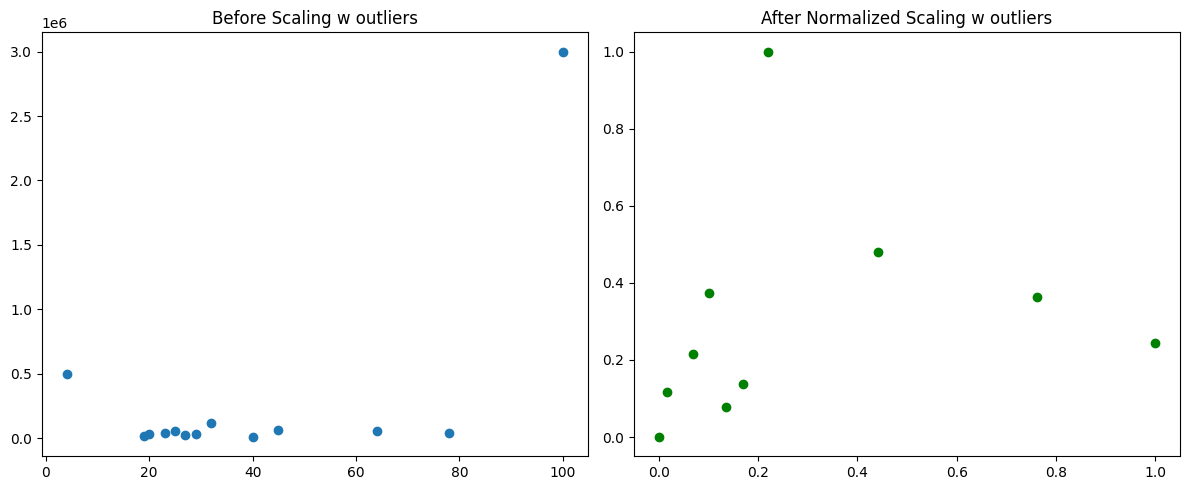

In [9]:
# scatter plot on standardization after adding outliers
from turtle import color


fig,(ax1,ax2)= plt.subplots(ncols=2,figsize=(12,5))

# left plot
ax1.set_title("Before Scaling w oultiers")
ax1.scatter(myData["age"],myData["income"])

# right plot
ax2.set_title("After Standard Scaling w outliers")
ax2.scatter(myData_scaled["age"],myData_scaled["income"],color="red")

plt.tight_layout()
plt.show() # prediction: i think there is no effect of scaling on the data, the shape and structure remains same. only scale differs.


# scatter plot on normalization after adding outliers
fig,(ax1,ax2)= plt.subplots(ncols=2,figsize=(12,5))

# left plot
ax1.set_title("Before Scaling w outliers")
ax1.scatter(myData["age"],myData["income"])

# right plot
ax2.set_title("After Normalized Scaling w outliers")
ax2.scatter(myData_normalized["age"],myData_normalized["income"],color="green")

plt.tight_layout()
plt.show() # prediction: no effect of normalization on scaling. maybe only scale will change


In [10]:
#scale the data uisng z-score normalization using class StanndardScaler
scaler = StandardScaler()
myData_scaled = scaler.fit_transform(myData) # we are fitting and transforming in one step
myData_scaled = pd.DataFrame(myData_scaled, columns=myData.columns)

 # we can also scale the data using normalization (MinMax normalization)
normalizer = MinMaxScaler()
myData_normalized = normalizer.fit_transform(myData)
myData_normalized = pd.DataFrame(myData_normalized,columns=myData.columns)

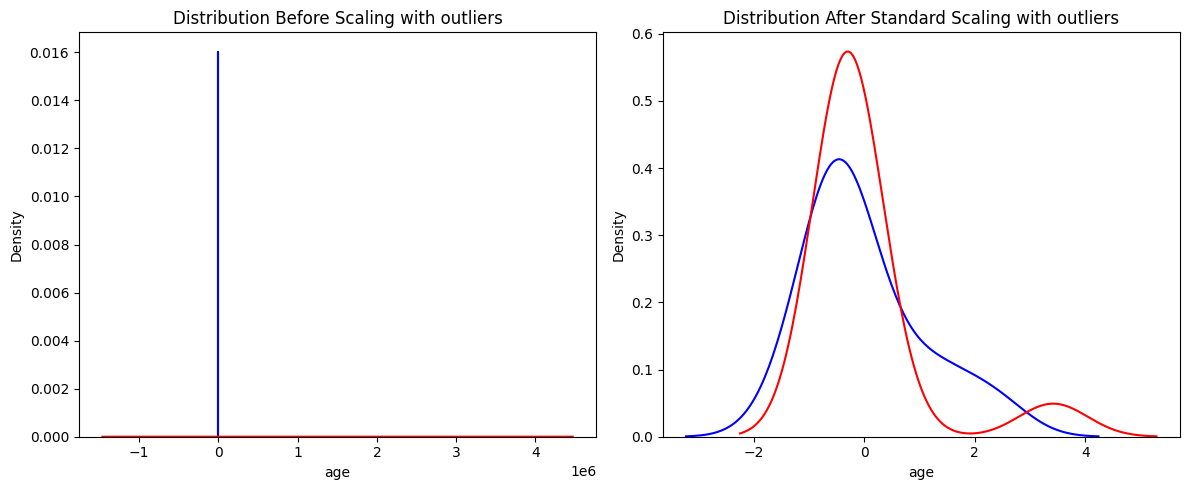

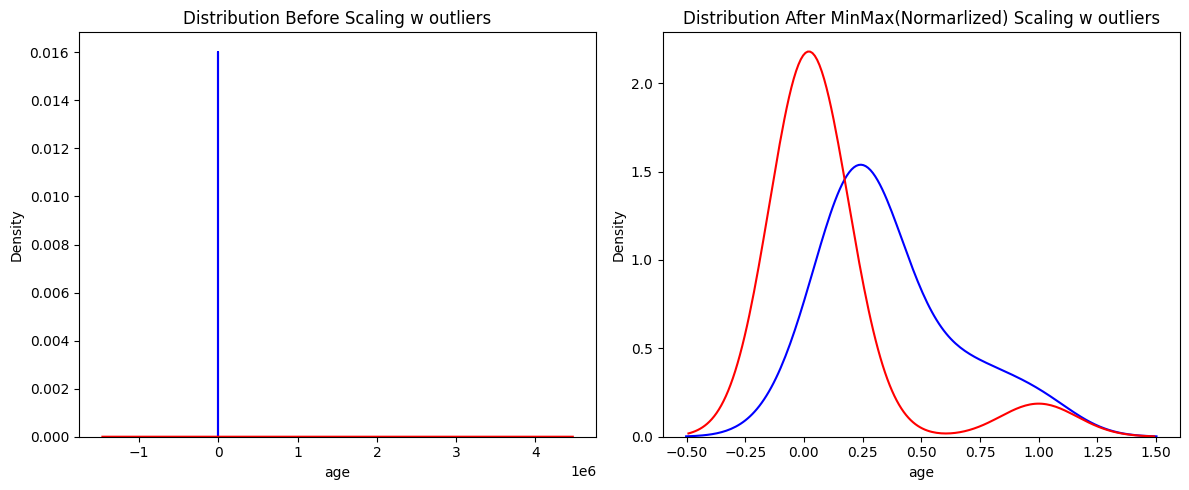

In [20]:
#  distribution plot on standard scaling after adding outliers
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(12,5)) # this line is just to display plots side by side 

# left plot
ax1.set_title("Distribution Before Scaling with outliers")
sns.kdeplot(myData["age"],color="blue",fill=False, ax=ax1)
sns.kdeplot(myData["income"],color="red",fill=False,ax=ax1)


# right plot 
ax2.set_title("Distribution After Standard Scaling with outliers")
sns.kdeplot(myData_scaled["age"],color="blue",fill=False,ax=ax2)
sns.kdeplot(myData_scaled["income"],color="red",fill=False,ax=ax2)

plt.tight_layout()
plt.show() # prediction: when scaled, all the values will be in equal footing (with in a small range), so the distribution plot might look like a regular guassian bell curve

# distribution plot on normalized scaling after adding ouliers
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(12,5)) # this line is just to display plots side by side 

# left plot
ax1.set_title("Distribution Before Scaling w outliers")
sns.kdeplot(myData["age"],color="blue",fill=False, ax=ax1)
sns.kdeplot(myData["income"],color="red",fill=False,ax=ax1)


# right plot
ax2.set_title("Distribution After MinMax(Normarlized) Scaling w outliers")
sns.kdeplot(myData_normalized["age"],color="blue",fill=False,ax=ax2)
sns.kdeplot(myData_normalized["income"],color="red",fill=False,ax=ax2)

plt.tight_layout()
plt.show() # prediction: since all the vaules are scaled bw 0 and 1.they are in equal footing and it's distribution plot may also look like a normal gaussian bell curve

## now, Lets try that in a real dataset
since this is already a big dataset, ouliers are not seperately studied and analyzed.<br>
detailed oulier analysis has been done above.

In [12]:
ads = pd.read_csv("Social_Network_Ads.csv")
ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [13]:
scaler = StandardScaler()
ads_scaled = scaler.fit_transform(ads[["Age","EstimatedSalary"]])
ads_scaled = pd.DataFrame(ads_scaled,columns=["Age","EstimatedSalary"])

In [14]:
# normalization(MinMax scaling)
normalizer = MinMaxScaler()
ads_normalized = normalizer.fit_transform(ads[["Age","EstimatedSalary"]])
ads_normalized = pd.DataFrame(ads_normalized,columns=["Age","EstimatedSalary"])


# Effect of scaling on data and relationship bw variables

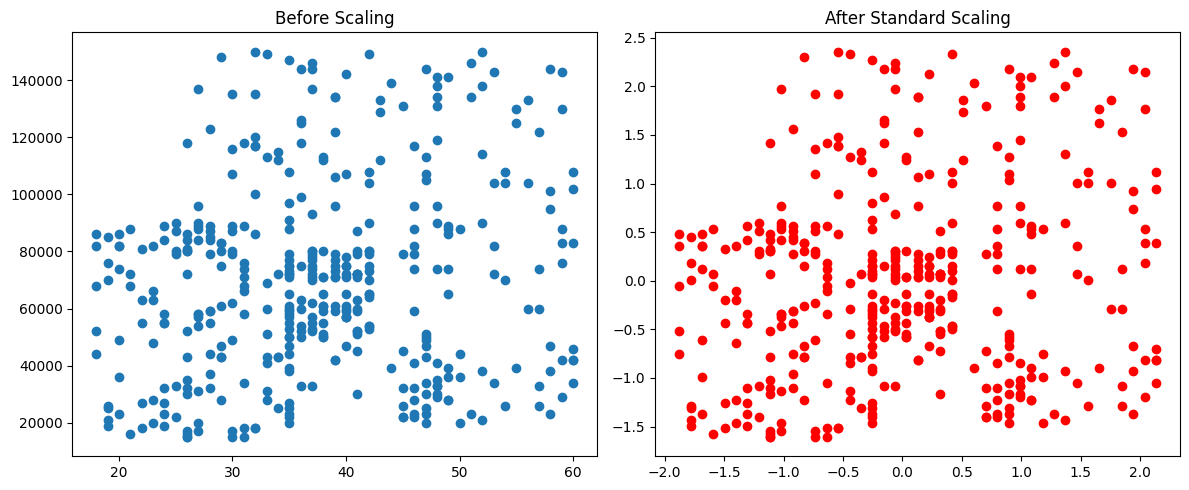

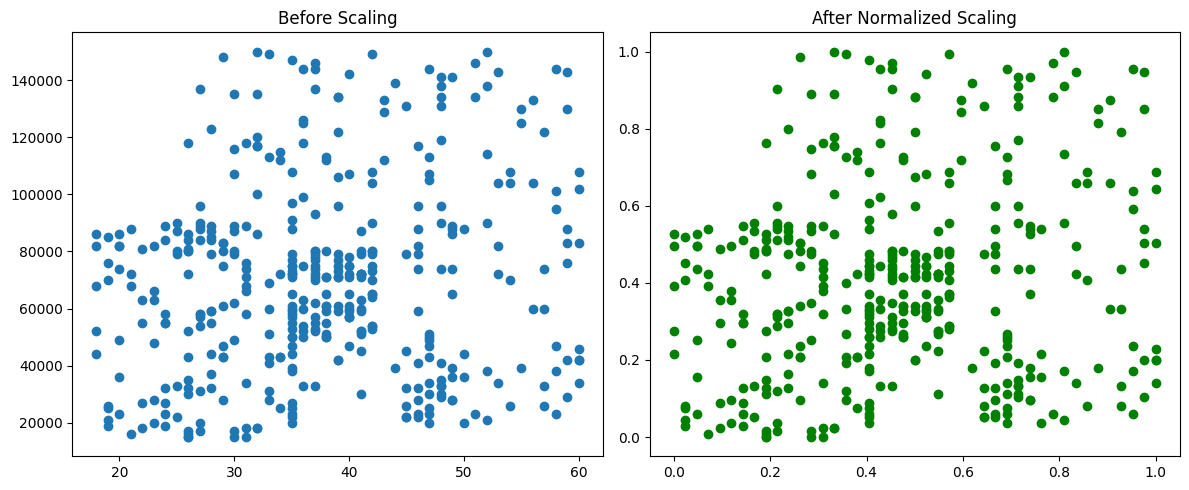

In [15]:
# scatter plot on standardizaton
from turtle import color


fig,(ax1,ax2)= plt.subplots(ncols=2,figsize=(12,5))

# left plot
ax1.set_title("Before Scaling")
ax1.scatter(ads["Age"],ads["EstimatedSalary"])

# right plot
ax2.set_title("After Standard Scaling")
ax2.scatter(ads_scaled["Age"],ads_scaled["EstimatedSalary"],color="red")

plt.tight_layout()
plt.show() # prediction: no effect on shape and structure, just the scale changes, data points are centered around 0 in both axes.

# scatter plot on normalization
fig,(ax1,ax2)= plt.subplots(ncols=2,figsize=(12,5))

# left plot
ax1.set_title("Before Scaling")
ax1.scatter(ads["Age"],ads["EstimatedSalary"])

# right plot
ax2.set_title("After Normalized Scaling")
ax2.scatter(ads_normalized["Age"],ads_normalized["EstimatedSalary"],color="green")

plt.tight_layout()
plt.show() # prediction: no effect on shape and structure,just the scale changes, data points may not be centered around 0.



## Visualizing effects of scaling on distributions

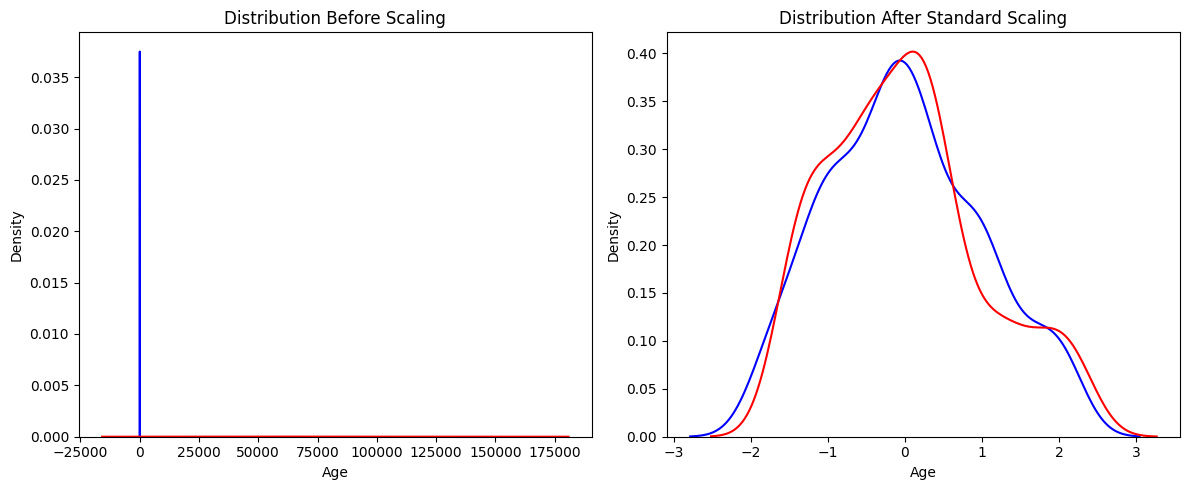

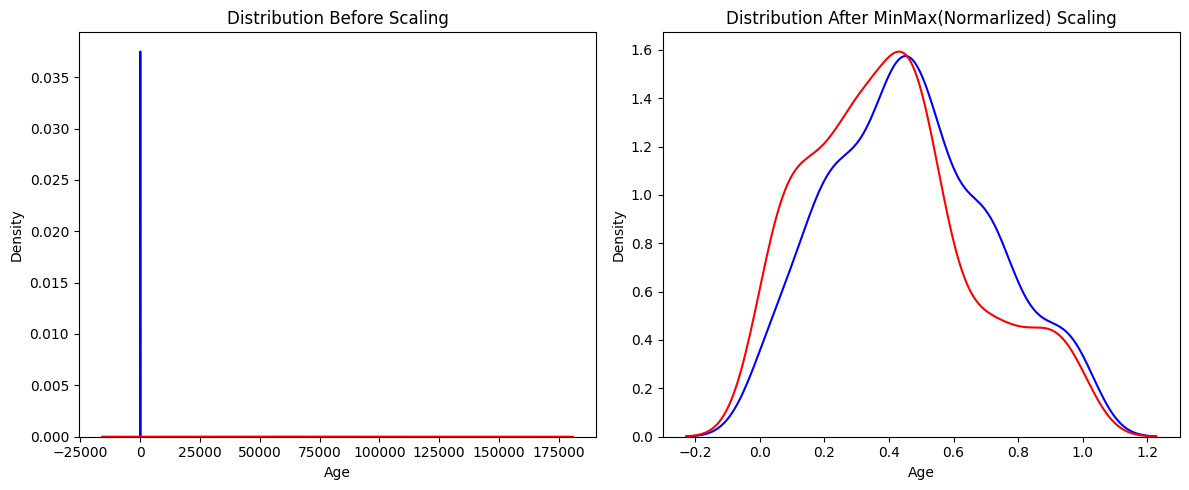

In [16]:
# distribution plot on standard scaling 
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

#left plot
sns.kdeplot(ads,x="Age",color="blue",fill = False,ax=ax1)
sns.kdeplot(ads,x="EstimatedSalary",color="red",fill= False,ax=ax1)
ax1.set_title("Distribution Before Scaling")

# right plot
sns.kdeplot(ads_scaled,x="Age",color="blue",fill= False,ax=ax2)
sns.kdeplot(ads_scaled,x="EstimatedSalary",color="red",fill= False,ax=ax2)
ax2.set_title("Distribution After Standard Scaling")

plt.tight_layout()
plt.show()


# distribution plot on normalized scaling 
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(12,5)) # this line is just to display plots side by side 

# left plot
ax1.set_title("Distribution Before Scaling")
sns.kdeplot(ads,x="Age",color="blue",fill=False, ax=ax1)
sns.kdeplot(ads,x="EstimatedSalary",color="red",fill=False,ax=ax1) # we can write this way,first mentioning df and choosing a feture inside that df as x


# right plot
ax2.set_title("Distribution After MinMax(Normarlized) Scaling") 
sns.kdeplot(ads_normalized["Age"],color="blue",fill=False,ax=ax2)# or we can directly give the feature without the haassle of mentioning df and assining x.
sns.kdeplot(ads_normalized["EstimatedSalary"],color="red",fill=False,ax=ax2)

plt.tight_layout()
plt.show()

In [17]:
# notice - the distribution plot 'red curve' of "Estimated Salary" after MinMax scaling is slightly different
# from the distribution plot 'red curve' of "EstimatedSalary" after Standard Scaling.

#after a little study into it: i got to know that,
    #If the distribution plot of the same feature looks different after MinMax and Standard scaling, 
    #it primarily indicates that the underlying data distribution is not symmetric 
    #(i.e., it is skewed or has heavy tails) and likely contains outliers. 

#Recommendation:
    #If the plots differ significantly due to outliers, consider using RobustScaler 
    # (which uses median and interquartile range) or applying a log/Box-Cox transformation
    # before scaling to handle skewness and reduce the impact of outliers. 

In [18]:
ads.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000
